In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [11]:


data_dict = {
    "id":   [1, 2, 3],
    "name": ["Alice", "Bob", "Carol"],
    "age":  [28, 35, 22],
    "city": ["Moscow", "SPb", "Kazan"],
}

df = pd.DataFrame(data_dict)

print(df)

   id   name  age    city
0   1  Alice   28  Moscow
1   2    Bob   35     SPb
2   3  Carol   22   Kazan


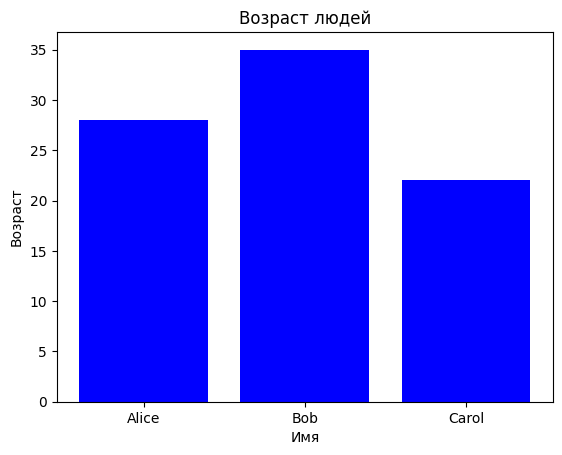

In [12]:
plt.bar(df["name"],df["age"],color="blue")
plt.title("Возраст людей")
plt.xlabel("Имя")
plt.ylabel("Возраст")
plt.show()

In [13]:
hist_data=pd.DataFrame({'values': np.random.normal(100,20,1000),})

In [15]:
hist_data

,values
0,108.337980
1,118.768918
2,100.830348
3,89.807924
4,55.545537
...,...
995,75.199437
996,95.137610
997,99.498295
998,115.817500


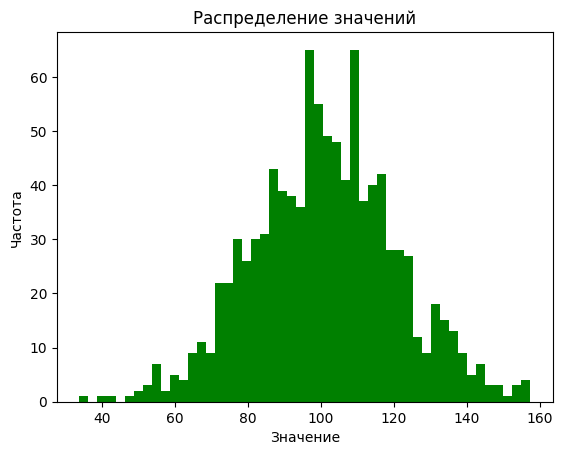

In [17]:
plt.hist(hist_data["values"],bins=50,color="green")
plt.title("Распределение значений")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

1.Самые популярные персонажи

2.Самые популярные локации

3.Персонажи, которые общаются между собой чаще всего

In [21]:
data = pd.read_csv("/content/simpsons_script_lines.csv",on_bad_lines="skip")

/tmp/ipykernel_2556/1707379761.py:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/simpsons_script_lines.csv",on_bad_lines="skip")


In [22]:
data

,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,9549,32,209,"Miss Hoover: No, actually, it was a little of ...",848000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...,31
1,9550,32,210,Lisa Simpson: (NEAR TEARS) Where's Mr. Bergstrom?,856000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,Where's Mr. Bergstrom?,wheres mr bergstrom,3
2,9551,32,211,Miss Hoover: I don't know. Although I'd sure l...,856000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,I don't know. Although I'd sure like to talk t...,i dont know although id sure like to talk to h...,22
3,9552,32,212,Lisa Simpson: That life is worth living.,864000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,That life is worth living.,that life is worth living,5
4,9553,32,213,Edna Krabappel-Flanders: The polls will be ope...,864000,True,40.0,3.0,Edna Krabappel-Flanders,Springfield Elementary School,The polls will be open from now until the end ...,the polls will be open from now until the end ...,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158266,9544,32,204,Miss Hoover: (OFF LISA'S REACTION) I'm back.,831000,true,464,3.0,Miss Hoover,Springfield Elementary School,I'm back.,im back,2
158267,9545,32,205,"Miss Hoover: You see, class, my Lyme disease t...",839000,true,464,3.0,Miss Hoover,Springfield Elementary School,"You see, class, my Lyme disease turned out to ...",you see class my lyme disease turned out to be,10
158268,9546,32,206,Miss Hoover: Psy-cho-so-ma-tic.,842000,true,464,3.0,Miss Hoover,Springfield Elementary School,Psy-cho-so-ma-tic.,psy-cho-so-ma-tic,1
158269,9547,32,207,Ralph Wiggum: Does that mean you were crazy?,844000,true,119,3.0,Ralph Wiggum,Springfield Elementary School,Does that mean you were crazy?,does that mean you were crazy,6


In [23]:
data.loc[2]

,2
id,9551
episode_id,32
number,211
raw_text,Miss Hoover: I don't know. Although I'd sure l...
timestamp_in_ms,856000
speaking_line,True
character_id,464.0
location_id,3.0
raw_character_text,Miss Hoover
raw_location_text,Springfield Elementary School


In [42]:
data["raw_character_text"].value_counts().tolist()[5]

2864

In [44]:
sum(data["raw_character_text"].value_counts().tolist()[5:])

68297

In [49]:
def drawTopchars(charsCount=5):
  topChars = data["raw_character_text"].value_counts().index[:charsCount]
  charsFreq = data["raw_character_text"].value_counts().tolist()[:charsCount]
  topChars=topChars.tolist()
  topChars.append("Остальные")
  charsFreq.append(sum(data["raw_character_text"].value_counts().tolist()[charsCount:]))

  plt.figure(figsize=(8,8))
  plt.pie(charsFreq, labels=topChars)
  plt.show()

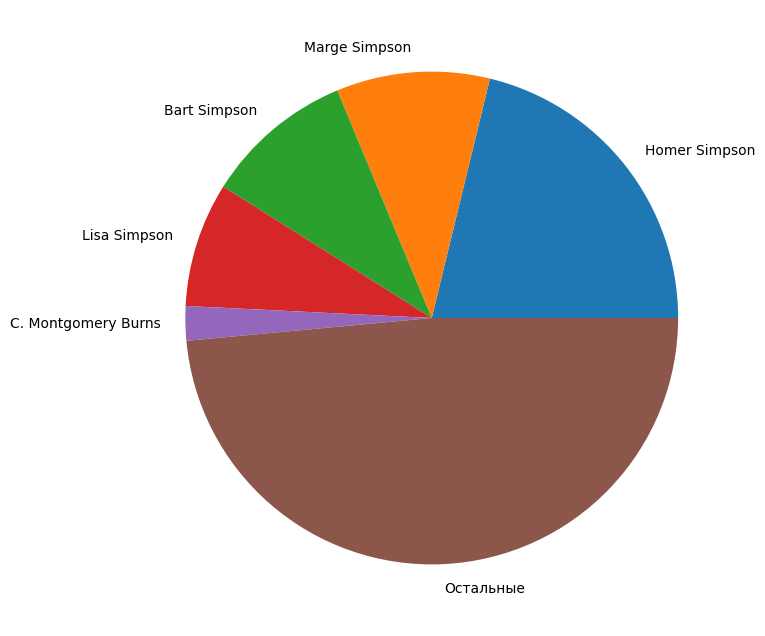

In [52]:
drawTopchars(5)

In [55]:
def drawTopLocs(number):
  topLocations = data["raw_location_text"].value_counts().index[:number]
  locsFreq = data["raw_location_text"].value_counts().tolist()[:number]


  topLocations=topLocations.tolist()
  topLocations.append("Остальные")
  locsFreq.append(sum(data["raw_location_text"].value_counts().tolist()[number:]))

  fig=plt.figure(figsize=(15,10))

  plt.barh(topLocations, locsFreq)

  plt.ylabel("Локация")
  plt.xlabel("Количество появлений")
  plt.title("Самые популярные локации")

  plt.show()


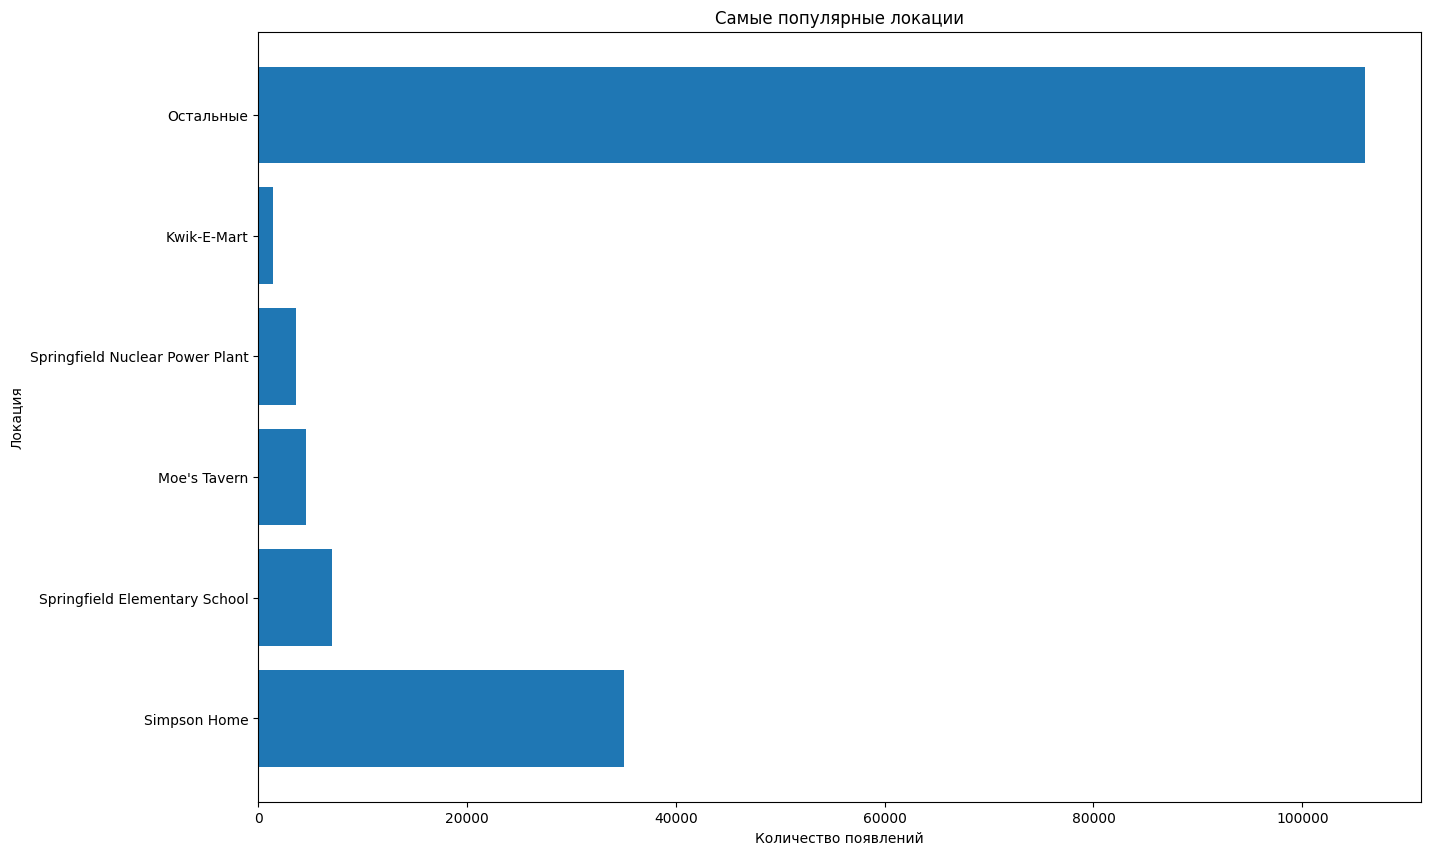

In [56]:
drawTopLocs(5)

In [59]:
data

,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,9549,32,209,"Miss Hoover: No, actually, it was a little of ...",848000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...,31
1,9550,32,210,Lisa Simpson: (NEAR TEARS) Where's Mr. Bergstrom?,856000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,Where's Mr. Bergstrom?,wheres mr bergstrom,3
2,9551,32,211,Miss Hoover: I don't know. Although I'd sure l...,856000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,I don't know. Although I'd sure like to talk t...,i dont know although id sure like to talk to h...,22
3,9552,32,212,Lisa Simpson: That life is worth living.,864000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,That life is worth living.,that life is worth living,5
4,9553,32,213,Edna Krabappel-Flanders: The polls will be ope...,864000,True,40.0,3.0,Edna Krabappel-Flanders,Springfield Elementary School,The polls will be open from now until the end ...,the polls will be open from now until the end ...,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158266,9544,32,204,Miss Hoover: (OFF LISA'S REACTION) I'm back.,831000,true,464,3.0,Miss Hoover,Springfield Elementary School,I'm back.,im back,2
158267,9545,32,205,"Miss Hoover: You see, class, my Lyme disease t...",839000,true,464,3.0,Miss Hoover,Springfield Elementary School,"You see, class, my Lyme disease turned out to ...",you see class my lyme disease turned out to be,10
158268,9546,32,206,Miss Hoover: Psy-cho-so-ma-tic.,842000,true,464,3.0,Miss Hoover,Springfield Elementary School,Psy-cho-so-ma-tic.,psy-cho-so-ma-tic,1
158269,9547,32,207,Ralph Wiggum: Does that mean you were crazy?,844000,true,119,3.0,Ralph Wiggum,Springfield Elementary School,Does that mean you were crazy?,does that mean you were crazy,6


In [67]:
def showDialogue(charNumber):
  topCharacters = data["raw_character_text"].value_counts().index[:charNumber]

  filtered = data[data.raw_character_text.isin(topCharacters)]

  dialogue = {
      "x1":filtered.raw_character_text[:-1].values,
      "x2":filtered.raw_character_text[1:].values
  }

  dialogue = pd.DataFrame.from_dict(dialogue)

  dialogue = dialogue[dialogue.x1 != dialogue.x2]

  dialogue = pd.get_dummies(dialogue.x2).groupby(dialogue.x1).apply(sum)

  fig,ax = plt.subplots(figsize=(9,7))

  im= ax.imshow(dialogue.values)

  ax.set_xticks(np.arange(len(dialogue.columns)))
  ax.set_yticks(np.arange(len(dialogue.index)))
  ax.set_xticklabels(dialogue.columns,rotation=45)
  ax.set_yticklabels(dialogue.index)

  for i in range(len(dialogue.index)):
    for j in range(len(dialogue.columns)):
      text = ax.text(j,i,int(dialogue.values[i,j]),ha="center",va="center",color="w")


  plt.colorbar(im,ax=ax)
  ax.set_title("Частота диалогов")
  ax.set_xlabel("Персонаж 1")
  ax.set_ylabel("Персонаж 2")
  plt.show()

/tmp/ipykernel_2556/3293137006.py:15: FutureWarning: The provided callable <built-in function sum> is currently using np.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.sum instead.
  dialogue = pd.get_dummies(dialogue.x2).groupby(dialogue.x1).apply(sum)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


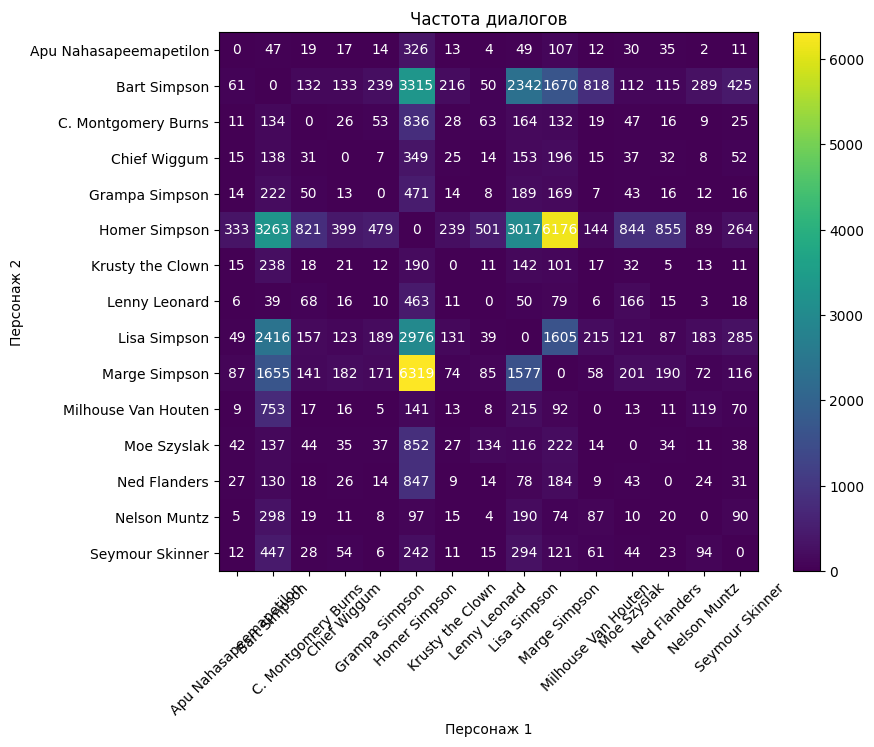

In [71]:
showDialogue(15)